In [1]:
import ast
import json
import re
import requests

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from bootcampviztools import plot_grouped_histograms
from toolbox_ML_v2 import describe_df, tipifica_variables

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import  KNeighborsRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import cross_val_score


from utils import extraer_informacion, obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features
import bootcampviztools as bt

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|') 

# Extracción de datos

In [2]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df])
df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/madrid/537745.html


# Train test split

In [3]:
X = df.drop(columns='precio')
y = df['precio'].replace(' €', '', regex=True).apply(ast.literal_eval).apply(lambda x: x.get('price')).str.replace('.', '').astype(int)
y.describe() 

count    1.217000e+03
mean     2.985689e+05
std      1.842492e+05
min      4.490000e+04
25%      1.920000e+05
50%      2.500000e+05
75%      3.380000e+05
max      1.950000e+06
Name: precio, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(973, 11)
(244, 11)
(973,)
(244,)


# Pretratamiento de datos

In [5]:
DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
)

In [6]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:248: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [7]:
X_train_limpio.head()

,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord
432,4.0,112.0,2.0,40.485302,-3.351513,7.0,None,1,centralizada,1982,0,0,29,NaN,NaN,4,30.0,5,30.0,5,100.0,5,760.0,5,150.0,5,40.0,5,200.0,5,90.0,1,0,3,NaN
277,4.0,106.0,NaN,40.379202,-3.658662,NaN,None,0,None,1997,0,0,30,NaN,NaN,5,50.0,5,150.0,5,220.0,0,NaN,5,230.0,5,1300.0,5,610.0,5,200.0,0,0,2,NaN
721,1.0,43.0,1.0,40.379000,-3.633020,NaN,Independiente,1,Independiente,2008,0,0,23,NaN,NaN,5,310.0,5,510.0,5,440.0,2,1200.0,5,290.0,5,340.0,5,480.0,5,190.0,0,0,1,NaN
852,3.0,137.0,2.0,40.296502,-4.006082,NaN,Independiente,0,Independiente,2021,1,0,31,108.0,22.0,2,190.0,5,370.0,1,1100.0,0,NaN,4,680.0,2,1600.0,1,2200.0,5,1300.0,0,0,1,3.0
678,3.0,65.0,1.0,40.486002,-3.688323,NaN,None,0,Independiente,1960,0,0,22,133.0,74.0,5,110.0,5,270.0,5,90.0,5,480.0,5,70.0,5,160.0,5,270.0,5,80.0,1,0,0,2.0


# MiniEDA

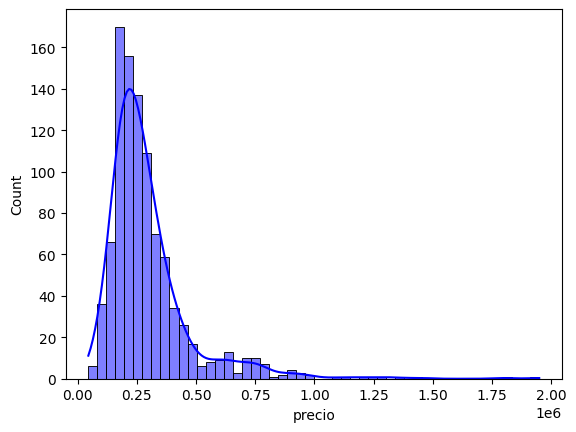

In [8]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

In [9]:
describe_df(X_train_limpio)

Clasificación sugerida para 973 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord
Columnas,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Tipo_Dato,float64,float64,float64,float64,float64,float64,object,int64,object,int64,int64,int64,int64,float64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,int64,int64,float64
Nulos,83,0,77,0,0,354,0,0,0,0,0,0,0,315,316,0,19,0,11,0,36,0,158,0,35,0,65,0,46,0,19,0,0,0,316
Nulos_%,8.5,0.0,7.9,0.0,0.0,36.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.4,32.5,0.0,2.0,0.0,1.1,0.0,3.7,0.0,16.2,0.0,3.6,0.0,6.7,0.0,4.7,0.0,2.0,0.0,0.0,0.0,32.5
Cardinalidad,6,163,4,827,950,13,3,2,3,96,2,2,46,419,277,6,75,6,80,6,87,6,108,6,98,6,114,6,114,6,104,2,2,4,7
Cardinalidad_%,0.62,16.75,0.41,84.99,97.64,1.34,0.31,0.21,0.31,9.87,0.21,0.21,4.73,43.06,28.47,0.62,7.71,0.62,8.22,0.62,8.94,0.62,11.1,0.62,10.07,0.62,11.72,0.62,11.72,0.62,10.69,0.21,0.21,0.41,0.72
Clasificacion_sugerida,Categorica_Nominal,Numerica_Continua,Categorica_Nominal,Numerica_Continua,Numerica_Continua,Numerica_Discreta,Categorica_Nominal,Categorica_Binaria,Categorica_Nominal,Numerica_Discreta,Categorica_Binaria,Categorica_Binaria,Numerica_Discreta,Numerica_Continua,Numerica_Continua,Categorica_Nominal,Numerica_Discreta,Categorica_Nominal,Numerica_Discreta,Categorica_Nominal,Numerica_Discreta,Categorica_Nominal,Numerica_Continua,Categorica_Nominal,Numerica_Continua,Categorica_Nominal,Numerica_Continua,Categorica_Nominal,Numerica_Continua,Categorica_Nominal,Numerica_Continua,Categorica_Binaria,Categorica_Binaria,Categorica_Nominal,Categorica_Nominal


In [10]:
binaria = tipifica_variables(X_train_limpio)['Categorica_Binaria']
categorica = tipifica_variables(X_train_limpio)['Categorica_Nominal']
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua

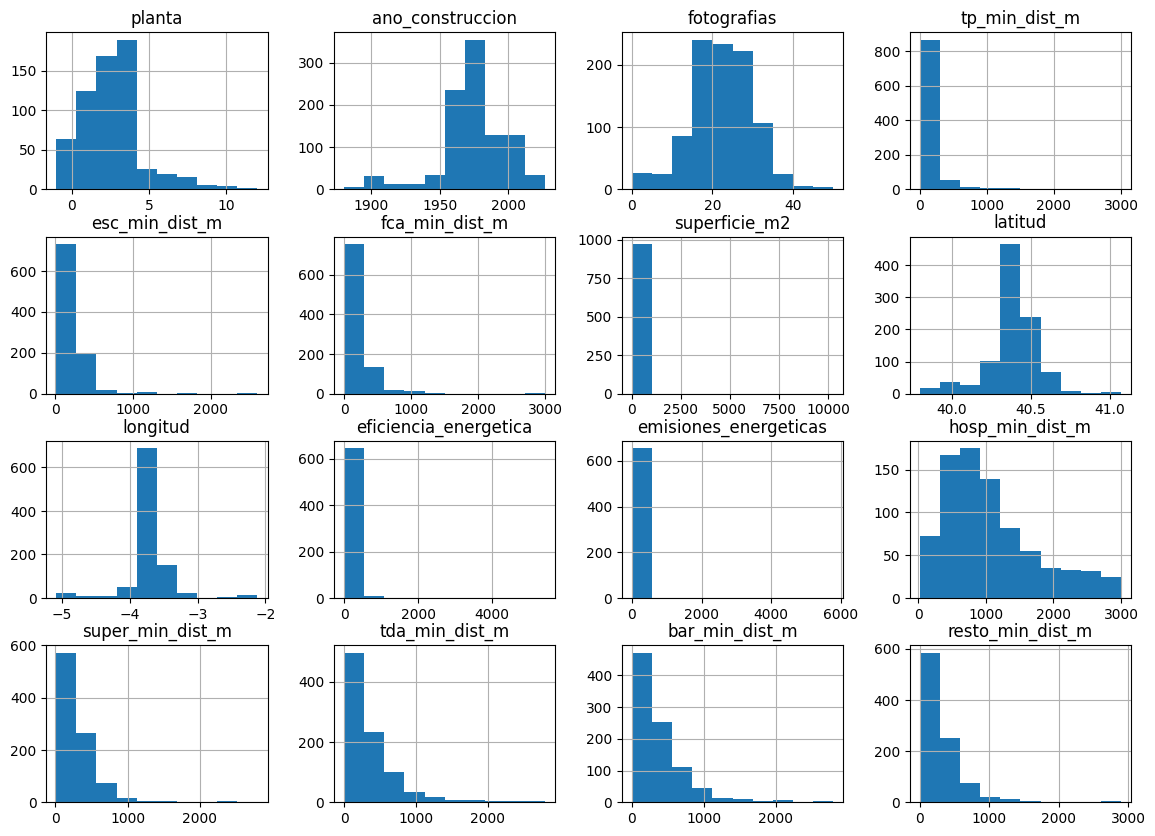

In [11]:
X_train_limpio[numericas].hist(figsize=(14, 10));

### Comparación de modelos

In [12]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_sel),
    ],
    remainder='drop'
)

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_sel),

    ],
    remainder='drop'
)

In [15]:
models = {
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(random_state=42, objective='reg:squarederror',),
    'LGBMRegressor': LGBMRegressor(random_state=42),
    'CatBoostRegressor': CatBoostRegressor(random_state=42, loss_function='RMSE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('features', pipe_features),
        ('preprocess', preprocess),
        ("model", model),
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,)
    rmse_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_RMSE': rmse_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_RMSE')


In [17]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    pipe = Pipeline(steps=[
        ('features', pipe_features),
        ('preprocess', preprocess_scale),
        ("model", model),
    ])

    scores_scale = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1,)
    rmse_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_RMSE': rmse_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_RMSE')
results_df

,model,mean_RMSE
4,CatBoostRegressor,89969.278023
2,XGBRegressor,102568.955027
1,RandomForest,103169.598336
3,LGBMRegressor,104288.734441
0,DecisionTree,125988.042275
7,knn_reg_5,136483.443540
10,knn_reg_5,136483.443540
6,knn_reg_3,139629.848382
9,knn_reg_3,139629.848382
5,lr_reg,422151.282674


En la comparación inicial, el mejor desempeño lo obtuvo CatBoostRegressor con un RMSE medio de aproximadamente 85.000 €, seguido por XGBoost (~94.000 €), Random Forest (~98.000 €) y LightGBM (~102.000 €); en cambio, KNN quedó bastante por detrás (~136–139k) y la regresión lineal fue claramente la peor (~340k), lo que sugiere que la relación entre las variables y el precio no es lineal y que los modelos basados en árboles y boosting capturan mejor interacciones y no linealidades.   

Al analizar la distribución del precio objetivo, se observa un mínimo cercano a 44.900 €, una mediana alrededor de 250.000 €, un percentil 75 de aproximadamente 338.000 € y un máximo de 1.950.000 €, muy extremo respecto del resto, lo que indica una distribución asimétrica con cola derecha y presencia de outliers(como vimos en el grafico del target anteriormente). En este contexto, un RMSE de ~85.000 € puede parecer relativamente “aceptable” en el rango central (aprox. 250–338k), pero resulta muy grande en términos relativos para viviendas baratas (por ejemplo, cerca de 45k implica errores comparables o incluso superiores al propio precio), por lo que además de RMSE conviene incorporar métricas de error relativo (como MAPE o MAE/mediana) y revisar si los modelos fallan de forma desproporcionada en los extremos (viviendas muy caras o muy baratas).

### Ajuste de hiperparametros

In [ ]:
cat_base = CatBoostRegressor(random_state=42, loss_function="RMSE",verbose=False,)

pipe_cat = Pipeline(steps=[
        ('features', pipe_features),
        ('preprocess', preprocess),
        ("model", cat_base),
    ])


param_grid_cat = {
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__iterations': [400, 800, 1200],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__random_strength': [0.5, 1.0, 2.0],
}

grid_cat = GridSearchCV(
    estimator = pipe_cat,
    param_grid = param_grid_cat,
    cv = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose = 1,
)

grid_cat.fit(X_train, y_train)

best_rmse = -grid_cat.best_score_

print("Mejores hiperparámetros:", grid_cat.best_params_)
print("Mejor RMSE CV:", best_rmse)

In [ ]:
xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

pipe_xgb = Pipeline(steps=[
    ('features', pipe_features),
    ('preprocess', preprocess),
    ('model', xgb_base),
])

param_grid_xgb = {
    'model__n_estimators': [400, 800, 1200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [3, 5, 7, 9],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__reg_alpha': [0.0, 0.1, 1.0],
    'model__reg_lambda': [1.0, 3.0, 10.0],
}

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_rmse = -grid_xgb.best_score_

print("Mejores hiperparámetros:", grid_xgb.best_params_)
print("Mejor RMSE CV:", best_rmse)


Fitting 5 folds for each of 8748 candidates, totalling 43740 fits
